# Customer Churn Prediction using Data Analytics and AI
**Internship:** AICTE | IBM SkillsBuild Data Analytics with AI Internship 2026 | BharatCares  
**Dataset:** IBM Telco Customer Churn (7,043 customers, 21 columns)

**Goal:** Find out which customers are likely to leave a telecom company, and why, so the company can act before they leave.

**Steps in this notebook**
1. Load and clean the data
2. Explore the data with charts (EDA)
3. Prepare the data for machine learning
4. Train and compare 3 models
5. Check the best model in detail
6. Business findings and recommendations

## 1. Import libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, classification_report)

sns.set_theme(style="whitegrid")
os.makedirs("figures", exist_ok=True)
RANDOM_STATE = 42

## 2. Load the data

In [2]:
URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

try:
    df = pd.read_csv(URL)
    print("Loaded from IBM GitHub link")
except Exception:
    df = pd.read_csv("churn.csv")   # local copy if there is no internet
    print("Loaded from local file")

print("Rows, columns:", df.shape)
df.head()

Loaded from IBM GitHub link
Rows, columns: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Data cleaning

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# TotalCharges is text in the file. Convert it to numbers.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Missing values after conversion:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())

Missing values after conversion:
TotalCharges    11
dtype: int64

Duplicate rows: 0


In [5]:
# The 11 missing rows are new customers with tenure = 0 (they have not been billed yet).
print(df[df["TotalCharges"].isnull()][["tenure", "MonthlyCharges", "TotalCharges"]].head())

# Only 11 of 7,043 rows (0.16%), so we drop them.
df = df.dropna(subset=["TotalCharges"]).reset_index(drop=True)

# customerID is only a label. It has no use for prediction.
df = df.drop(columns=["customerID"])

# Make SeniorCitizen readable and make target 0/1
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})
df["ChurnFlag"] = (df["Churn"] == "Yes").astype(int)
print("Clean shape:", df.shape)

      tenure  MonthlyCharges  TotalCharges
488        0           52.55           NaN
753        0           20.25           NaN
936        0           80.85           NaN
1082       0           25.75           NaN
1340       0           56.05           NaN
Clean shape: (7032, 21)


## 4. Exploratory Data Analysis (EDA)

### 4.1 How many customers leave?

Churn rate: 26.6%


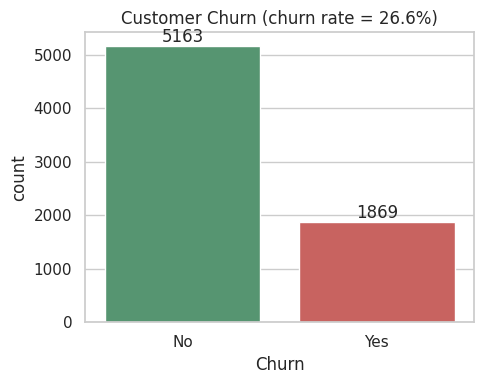

In [6]:
rate = df["ChurnFlag"].mean() * 100
print(f"Churn rate: {rate:.1f}%")

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x="Churn", palette=["#4C9F70", "#D9534F"], ax=ax)
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
ax.set_title(f"Customer Churn (churn rate = {rate:.1f}%)")
plt.tight_layout(); plt.savefig("figures/01_churn_count.png", dpi=150); plt.show()

**Finding:** About 1 in 4 customers leave. The data is imbalanced (more 'No' than 'Yes'), so accuracy alone is not a good score. We will also check recall, F1 and ROC-AUC.

### 4.2 Contract type

Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: ChurnFlag, dtype: float64


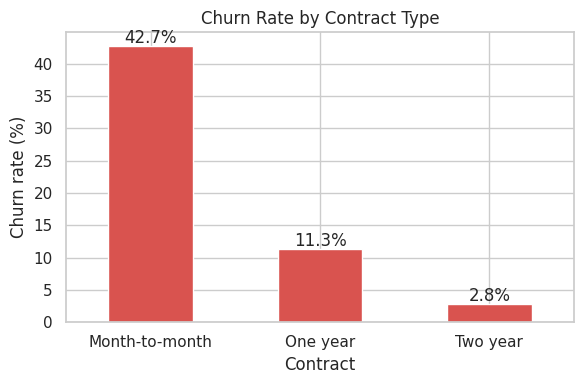

In [7]:
ct = df.groupby("Contract")["ChurnFlag"].mean().mul(100).round(1)
print(ct)

fig, ax = plt.subplots(figsize=(6, 4))
ct.plot(kind="bar", color="#D9534F", ax=ax)
ax.set_ylabel("Churn rate (%)"); ax.set_title("Churn Rate by Contract Type")
plt.xticks(rotation=0)
for i, v in enumerate(ct): ax.text(i, v + 0.5, f"{v}%", ha="center")
plt.tight_layout(); plt.savefig("figures/02_churn_by_contract.png", dpi=150); plt.show()

**Finding:** Month-to-month customers leave far more than customers on 1-year or 2-year contracts.

### 4.3 Tenure (how long they have been a customer)

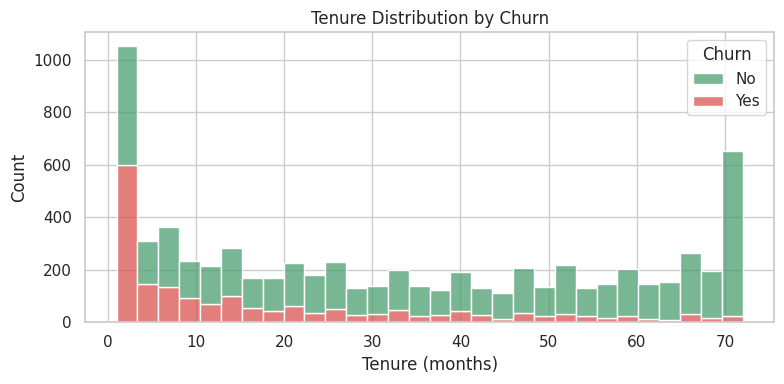

Churn
No     38.0
Yes    10.0
Name: tenure, dtype: float64


In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, multiple="stack",
             palette=["#4C9F70", "#D9534F"], ax=ax)
ax.set_title("Tenure Distribution by Churn"); ax.set_xlabel("Tenure (months)")
plt.tight_layout(); plt.savefig("figures/03_tenure.png", dpi=150); plt.show()

print(df.groupby("Churn")["tenure"].median())

**Finding:** Most churn happens in the first few months. Customers who stay past the first year are much safer.

### 4.4 Monthly charges

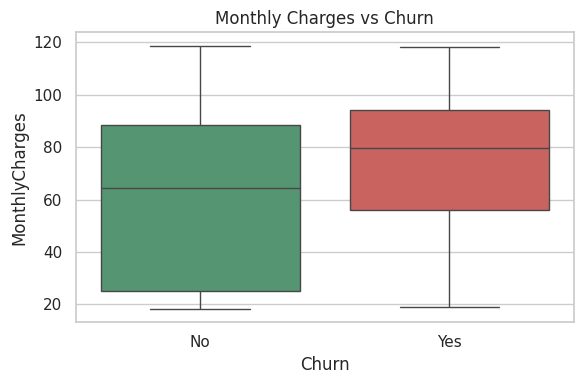

Churn
No     64.45
Yes    79.65
Name: MonthlyCharges, dtype: float64


In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", palette=["#4C9F70", "#D9534F"], ax=ax)
ax.set_title("Monthly Charges vs Churn")
plt.tight_layout(); plt.savefig("figures/04_monthly_charges.png", dpi=150); plt.show()
print(df.groupby("Churn")["MonthlyCharges"].median())

**Finding:** Customers who leave pay more per month on average.

### 4.5 Internet service and payment method

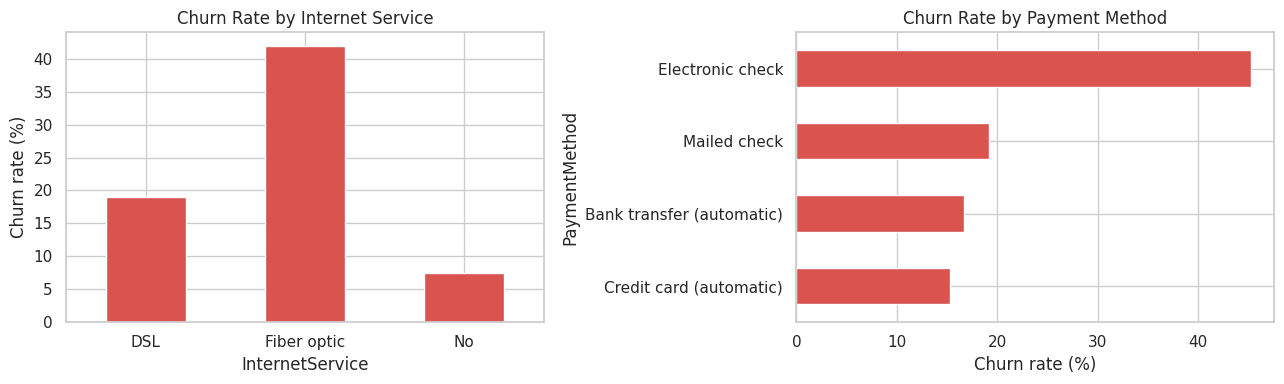

InternetService
DSL            19.0
Fiber optic    41.9
No              7.4
Name: ChurnFlag, dtype: float64 

PaymentMethod
Credit card (automatic)      15.3
Bank transfer (automatic)    16.7
Mailed check                 19.2
Electronic check             45.3
Name: ChurnFlag, dtype: float64


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

a = df.groupby("InternetService")["ChurnFlag"].mean().mul(100).round(1)
a.plot(kind="bar", color="#D9534F", ax=axes[0])
axes[0].set_title("Churn Rate by Internet Service"); axes[0].set_ylabel("Churn rate (%)")
axes[0].tick_params(axis="x", rotation=0)

b = df.groupby("PaymentMethod")["ChurnFlag"].mean().mul(100).round(1).sort_values()
b.plot(kind="barh", color="#D9534F", ax=axes[1])
axes[1].set_title("Churn Rate by Payment Method"); axes[1].set_xlabel("Churn rate (%)")

plt.tight_layout(); plt.savefig("figures/05_internet_payment.png", dpi=150); plt.show()
print(a, "\n"); print(b)

**Finding:** Fiber optic customers and electronic check payers churn the most.

### 4.6 Support services

                  Has service  No service
Service                                  
OnlineSecurity           14.6        41.8
TechSupport              15.2        41.6
OnlineBackup             21.6        39.9
DeviceProtection         22.5        39.1


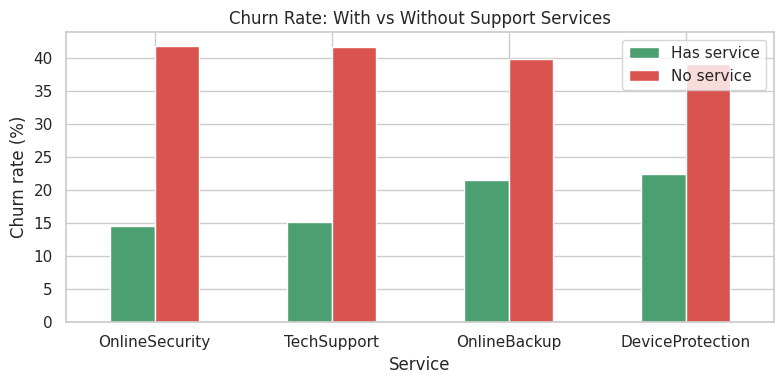

In [11]:
services = ["OnlineSecurity", "TechSupport", "OnlineBackup", "DeviceProtection"]
rows = []
for s in services:
    g = df[df[s].isin(["Yes", "No"])].groupby(s)["ChurnFlag"].mean() * 100
    rows.append({"Service": s, "Has service": g["Yes"], "No service": g["No"]})
sv = pd.DataFrame(rows).set_index("Service").round(1)
print(sv)

sv.plot(kind="bar", figsize=(8, 4), color=["#4C9F70", "#D9534F"])
plt.ylabel("Churn rate (%)"); plt.title("Churn Rate: With vs Without Support Services")
plt.xticks(rotation=0); plt.tight_layout()
plt.savefig("figures/06_services.png", dpi=150); plt.show()

**Finding:** Customers with online security or tech support churn much less (about 15%) than those without (about 42%).

### 4.7 Correlation of numbers

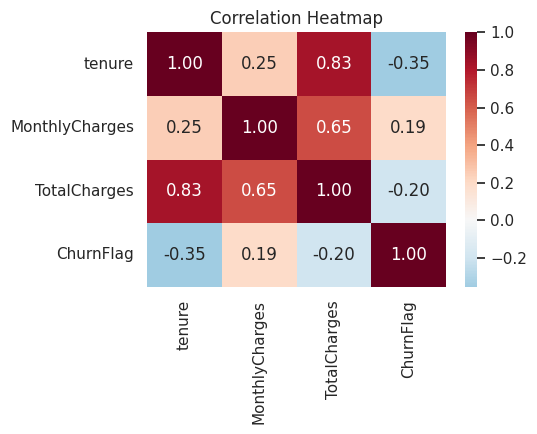

In [12]:
num_cols_eda = ["tenure", "MonthlyCharges", "TotalCharges", "ChurnFlag"]
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(df[num_cols_eda].corr(), annot=True, cmap="RdBu_r", center=0, fmt=".2f", ax=ax)
ax.set_title("Correlation Heatmap")
plt.tight_layout(); plt.savefig("figures/07_correlation.png", dpi=150); plt.show()

**Finding:** Tenure has a negative link with churn (longer stay = less churn). TotalCharges and tenure are strongly linked to each other, which is expected because TotalCharges is roughly tenure x monthly price.

## 5. Prepare data for machine learning

In [13]:
X = df.drop(columns=["Churn", "ChurnFlag"])
y = df["ChurnFlag"]

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = [c for c in X.columns if c not in num_cols]

# Stratify keeps the same churn ratio in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Churn rate in train: %.1f%%  | test: %.1f%%" % (y_train.mean()*100, y_test.mean()*100))

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore"), cat_cols),
])

Train: (5625, 19)  Test: (1407, 19)
Churn rate in train: 26.6%  | test: 26.6%


## 6. Train and compare models

We test 3 models. `class_weight="balanced"` is used where possible so the model pays more attention to the smaller 'churn' group.

- **Logistic Regression** – simple, fast, easy to explain
- **Random Forest** – many decision trees combined
- **Gradient Boosting** – trees built one after another, each fixing the last one's mistakes

In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=5,
                                            class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results, fitted = [], {}

for name, model in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    cv_auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc").mean()
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    fitted[name] = pipe
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba),
        "CV ROC-AUC (train)": cv_auc,
    })

res = pd.DataFrame(results).set_index("Model").round(3)
res

,Accuracy,Precision,Recall,F1,ROC-AUC,CV ROC-AUC (train)
Model,,,,,,
Logistic Regression,0.726,0.491,0.797,0.608,0.835,0.846
Random Forest,0.751,0.520,0.789,0.627,0.835,0.849
Gradient Boosting,0.796,0.641,0.529,0.580,0.839,0.847


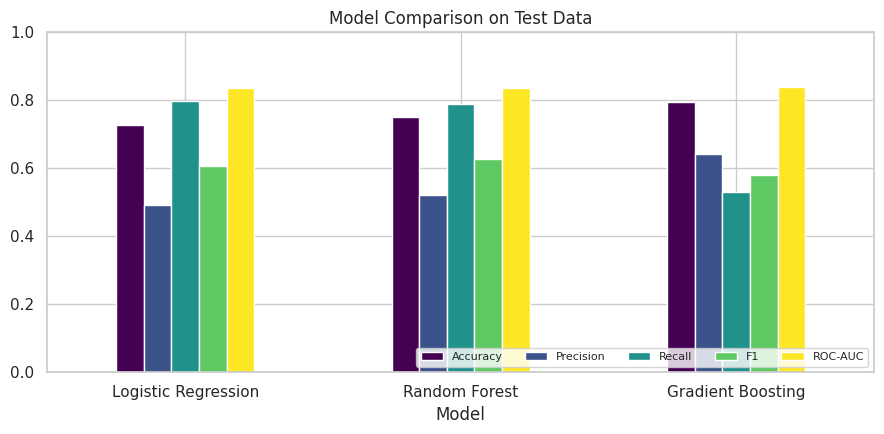

In [15]:
res[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]].plot(
    kind="bar", figsize=(9, 4.5), colormap="viridis")
plt.title("Model Comparison on Test Data"); plt.ylim(0, 1); plt.xticks(rotation=0)
plt.legend(loc="lower right", ncol=5, fontsize=8)
plt.tight_layout(); plt.savefig("figures/08_model_comparison.png", dpi=150); plt.show()

**How to read this**
- All 3 models have almost the same ROC-AUC (about 0.84), so ROC-AUC cannot separate them.
- Gradient Boosting has the highest accuracy, but it misses almost half of the customers who leave (recall 0.53).
- We choose the model with the best **F1 score**, because it balances catching churners (recall) and avoiding false alarms (precision).
- **Recall** = out of all customers who really left, how many did we catch?
- **Precision** = out of all customers we said would leave, how many really did?
- For churn, missing a customer who leaves (low recall) usually costs more than a wrong alarm, so recall matters a lot.

## 7. Best model in detail

In [16]:
best_name = res["F1"].idxmax()
best = fitted[best_name]
print("Best model by F1 score:", best_name)

pred = best.predict(X_test)
proba = best.predict_proba(X_test)[:, 1]
print(classification_report(y_test, pred, target_names=["Stayed", "Churned"]))

Best model by F1 score: Random Forest
              precision    recall  f1-score   support

      Stayed       0.91      0.74      0.81      1033
     Churned       0.52      0.79      0.63       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407



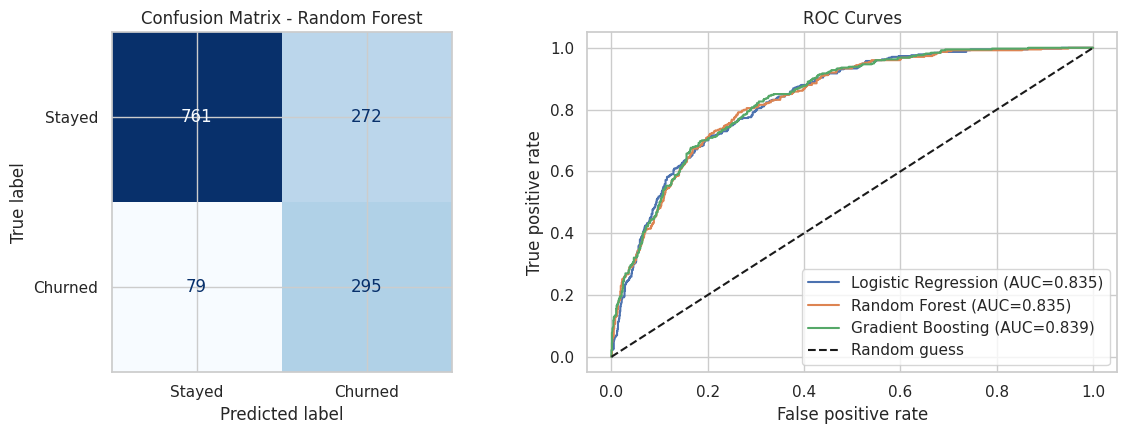

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=["Stayed", "Churned"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Confusion Matrix - {best_name}")

for name, pipe in fitted.items():
    fpr, tpr, _ = roc_curve(y_test, pipe.predict_proba(X_test)[:, 1])
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, pipe.predict_proba(X_test)[:,1]):.3f})")
axes[1].plot([0, 1], [0, 1], "k--", label="Random guess")
axes[1].set_xlabel("False positive rate"); axes[1].set_ylabel("True positive rate")
axes[1].set_title("ROC Curves"); axes[1].legend(loc="lower right")

plt.tight_layout(); plt.savefig("figures/09_confusion_roc.png", dpi=150); plt.show()

## 8. What drives churn? (Feature importance)

Random Forest importance shows **how much each column helps the model decide**. (We do not use Logistic Regression coefficients here because several columns overlap, for example MonthlyCharges, TotalCharges and tenure, which makes coefficients confusing to read.)

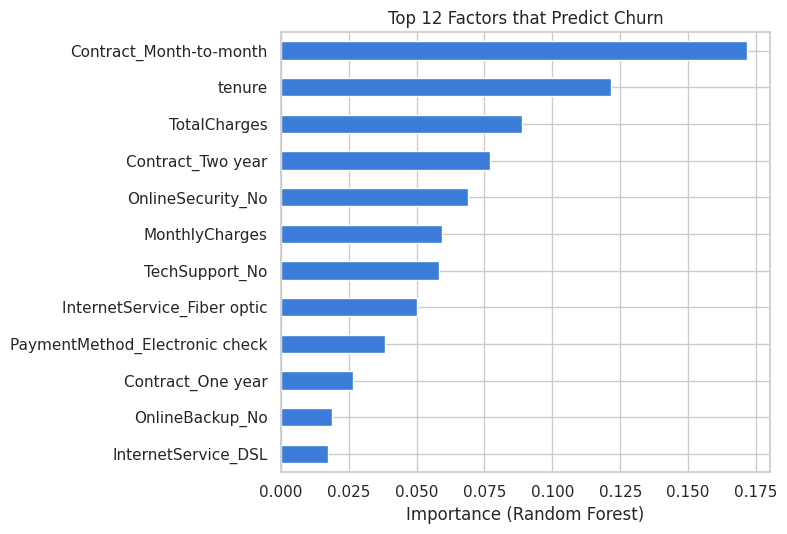

Contract_Month-to-month           0.172
tenure                            0.122
TotalCharges                      0.089
Contract_Two year                 0.077
OnlineSecurity_No                 0.069
MonthlyCharges                    0.059
TechSupport_No                    0.058
InternetService_Fiber optic       0.050
PaymentMethod_Electronic check    0.038
Contract_One year                 0.027
dtype: float64

In [18]:
rf = fitted["Random Forest"]
rf_names = [n.replace("num__", "").replace("cat__", "") for n in rf.named_steps["prep"].get_feature_names_out()]
rf_imp = pd.Series(rf.named_steps["model"].feature_importances_, index=rf_names).sort_values(ascending=False)

top = rf_imp.head(12).sort_values()
fig, ax = plt.subplots(figsize=(8, 5.5))
top.plot(kind="barh", color="#3B7DD8", ax=ax)
ax.set_title("Top 12 Factors that Predict Churn")
ax.set_xlabel("Importance (Random Forest)")
plt.tight_layout(); plt.savefig("figures/10_feature_importance.png", dpi=150); plt.show()
rf_imp.head(10).round(3)

## 9. Find high-risk customers

In [19]:
scored = X_test.copy()
scored["Churn_Probability"] = proba
scored["Actual"] = y_test.values
scored["Risk"] = pd.cut(scored["Churn_Probability"], [0, 0.4, 0.7, 1.0], labels=["Low", "Medium", "High"], include_lowest=True)

summary = scored.groupby("Risk", observed=True).agg(
    Customers=("Actual", "size"), Actual_Churn_Rate=("Actual", "mean")).round(3)
print(summary)

scored.sort_values("Churn_Probability", ascending=False).head(10)[
    ["tenure", "Contract", "InternetService", "MonthlyCharges", "Churn_Probability", "Actual"]].round(2)

        Customers  Actual_Churn_Rate
Risk                                
Low           727              0.081
Medium        371              0.321
High          309              0.634


,tenure,Contract,InternetService,MonthlyCharges,Churn_Probability,Actual
3374,1,Month-to-month,Fiber optic,95.10,0.92,1
4577,1,Month-to-month,Fiber optic,85.05,0.92,1
3154,3,Month-to-month,Fiber optic,94.85,0.92,0
3721,3,Month-to-month,Fiber optic,96.60,0.91,1
2792,3,Month-to-month,Fiber optic,100.95,0.91,1
2748,1,Month-to-month,Fiber optic,95.65,0.91,1
2392,1,Month-to-month,Fiber optic,88.35,0.91,1
2626,7,Month-to-month,Fiber optic,99.25,0.91,1
2459,1,Month-to-month,Fiber optic,77.15,0.91,1
641,1,Month-to-month,Fiber optic,89.55,0.90,1


If the risk groups work well, the churn rate should rise clearly from Low to High. This is what makes the model useful: the team can call the High group first.

## 10. Save results

In [20]:
res.to_csv("model_results.csv")
scored.sort_values("Churn_Probability", ascending=False).to_csv("high_risk_customers.csv", index=False)
print("Saved: model_results.csv, high_risk_customers.csv, and charts in /figures")

Saved: model_results.csv, high_risk_customers.csv, and charts in /figures


## 11. Conclusion and recommendations

**What we found (see charts above for numbers)**
- About 27% of customers churn (26.6%).
- Month-to-month contracts, short tenure, fiber optic internet, electronic check payment and higher monthly bills are linked to more churn.
- Customers with tech support, online security and long contracts stay longer.

**What the company can do**
1. Offer discounts to move month-to-month customers to 1-year or 2-year plans.
2. Give special attention in the first 12 months (welcome call, check-in).
3. Bundle tech support and online security for free or cheap for a trial period.
4. Check service quality and price for fiber optic customers.
5. Encourage automatic payments instead of electronic check.
6. Use the model to rank customers by churn risk and contact the High risk group first.

**Limits of this work**
- The data is a single snapshot. It does not show changes over time.
- The model finds patterns, not proof of cause. A discount test (A/B test) is needed to confirm what works.
- There is no cost data, so we cannot yet say how much a retention offer is worth per customer.

**Future work:** tune the models further, try XGBoost, add a cost-based threshold, and build a simple dashboard.